In [1]:
import pandas, seaborn
import scipy, scipy.stats
import matplotlib, matplotlib.pyplot

matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':12, 
                            'ytick.labelsize':8, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':16
                           })

In [2]:
metadata_file = '/Users/adrian/research/bmcbf/038_husavik/metadata/SraRunTable.csv'
metadata = pandas.read_csv(metadata_file, sep=',')
metadata.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_line,cell_type,Center Name,...,Organism,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,tissue,treatment
0,SRR24197676,RNA-Seq,276,10759270304,PRJNA956567,SAMN34226756,3478245489,A-673 (RRID:CVCL_0080),ewing sarcoma,"UMR1307 - CHILD, NANTES UNIVERSITY",...,Homo sapiens,ILLUMINA,2024-11-04T00:00:00Z,2023-04-17T22:33:00Z,1,GSM7180315,cell line,SRP433058,cell line,doxycyxline added
1,SRR24197677,RNA-Seq,278,8939073458,PRJNA956567,SAMN34226757,2853638452,A-673 (RRID:CVCL_0080),ewing sarcoma,"UMR1307 - CHILD, NANTES UNIVERSITY",...,Homo sapiens,ILLUMINA,2024-11-04T00:00:00Z,2023-04-17T22:28:00Z,1,GSM7180314,cell line,SRP433058,cell line,doxycyxline added
2,SRR24197678,RNA-Seq,268,10130964730,PRJNA956567,SAMN34226758,3242641919,A-673 (RRID:CVCL_0080),ewing sarcoma,"UMR1307 - CHILD, NANTES UNIVERSITY",...,Homo sapiens,ILLUMINA,2024-11-04T00:00:00Z,2023-04-17T22:32:00Z,1,GSM7180313,cell line,SRP433058,cell line,doxycyxline added
3,SRR24197679,RNA-Seq,278,10080652631,PRJNA956567,SAMN34226759,3232755233,A-673 (RRID:CVCL_0080),ewing sarcoma,"UMR1307 - CHILD, NANTES UNIVERSITY",...,Homo sapiens,ILLUMINA,2024-11-04T00:00:00Z,2023-04-17T22:32:00Z,1,GSM7180312,cell line,SRP433058,cell line,doxycyxline not added
4,SRR24197680,RNA-Seq,270,7926605486,PRJNA956567,SAMN34226760,2664832514,A-673 (RRID:CVCL_0080),ewing sarcoma,"UMR1307 - CHILD, NANTES UNIVERSITY",...,Homo sapiens,ILLUMINA,2024-11-04T00:00:00Z,2023-04-17T22:30:00Z,1,GSM7180311,cell line,SRP433058,cell line,doxycyxline not added


In [3]:
targets_file = '/Users/adrian/research/bmcbf/038_husavik/data/GENES involved in NCHH.xlsx'
df = pandas.read_excel(targets_file, sheet_name='canonical')
targets = list(df.iloc[:, 0].values)
targets[:10]

['CSNK1A1L',
 'CSNK1A1',
 'CSNK1D',
 'CSNK1E',
 'CSNK1G2',
 'CSNK1G3',
 'FBXW11',
 'GAS1',
 'STK36',
 'GLI1']

In [4]:
t2g_file = '/Users/adrian/software/kallisto/human_index_standard/t2g.txt'
rosetta = pandas.read_csv(t2g_file, sep='\t', header=None)

ensemblIDs = []

print(len(targets))

for target in targets:
    conversion = list(set(rosetta[rosetta[2] == target][1].values))
    if len(conversion) != 1:
        print('ERROR')
    ensemblID = conversion[0]
    print(target, ensemblID)
    ensemblIDs.append(ensemblID)

uniqueIDs = list(set(ensemblIDs))
print(len(uniqueIDs))

/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_14952/171639528.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  rosetta = pandas.read_csv(t2g_file, sep='\t', header=None)


56
CSNK1A1L ENSG00000180138.7
CSNK1A1 ENSG00000113712.19
CSNK1D ENSG00000141551.15
CSNK1E ENSG00000213923.13
CSNK1G2 ENSG00000133275.16
CSNK1G3 ENSG00000151292.19
FBXW11 ENSG00000072803.18
GAS1 ENSG00000180447.7
STK36 ENSG00000163482.12
GLI1 ENSG00000111087.10
GLI2 ENSG00000074047.22
GLI3 ENSG00000106571.15
GSK3B ENSG00000082701.17
BMP8A ENSG00000183682.8
IHH ENSG00000163501.7
LRP2 ENSG00000081479.15
DHH ENSG00000139549.4
WNT16 ENSG00000002745.13
SUFU ENSG00000107882.12
RAB23 ENSG00000112210.12
CSNK1G1 ENSG00000169118.18
WNT4 ENSG00000162552.15
PRKACA ENSG00000072062.16
PRKACB ENSG00000142875.20
PRKACG ENSG00000165059.8
PRKX ENSG00000183943.6
PTCH1 ENSG00000185920.18
HHIP ENSG00000164161.10
SHH ENSG00000164690.8
BMP2 ENSG00000125845.7
BMP4 ENSG00000125378.16
BMP5 ENSG00000112175.8
BMP6 ENSG00000153162.9
BMP7 ENSG00000101144.13
BMP8B ENSG00000116985.12
SMO ENSG00000128602.11
WNT1 ENSG00000125084.13
WNT2 ENSG00000105989.10
WNT3 ENSG00000108379.10
WNT5A ENSG00000114251.15
WNT6 ENSG0000011

In [5]:
expression_file = '/Users/adrian/research/bmcbf/038_husavik/results/DESeq2_TPM_values.transcripts.tsv'
df = pandas.read_csv(expression_file, sep='\t', index_col=0)
df

,SRR24197676,SRR24197677,SRR24197678,SRR24197679,SRR24197680,SRR24197681,SRR24197682,SRR24197683,SRR24197684,SRR24197685,...,SRR24197711,SRR24197712,SRR24197713,SRR24197714,SRR24197715,SRR24197716,SRR24197717,SRR24197718,SRR24197719,SRR24197720
ENSG00000000003.15,62.858977,31.771449,34.651158,56.669103,36.806233,37.290949,29.015099,30.991532,34.584786,27.309989,...,21.302521,34.348128,46.428343,42.798327,35.598414,35.165505,42.571532,34.402216,39.400808,38.400612
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.054277,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.415614,0.426898,0.374336,0.982474,0.869173,0.849658,0.000000,0.000000,0.000000
ENSG00000000419.14,86.389186,52.971897,49.156871,88.802819,50.403289,50.543090,106.185088,96.750511,99.288102,72.090502,...,84.687112,92.001194,116.577424,109.094536,36.587173,39.257637,58.972095,87.149778,89.534716,102.261067
ENSG00000000457.14,5.287378,2.571407,1.844020,3.880388,1.776324,1.846350,2.691707,2.473953,3.164968,3.104503,...,7.300535,4.356865,5.211349,4.800627,10.021584,11.218086,13.012265,4.130994,3.278623,3.154355
ENSG00000000460.17,25.095803,16.543945,13.670647,21.423212,16.454469,16.191112,16.214193,20.278728,19.783594,14.712733,...,27.305086,28.114061,20.685985,25.562383,42.361668,39.690778,31.410296,22.912470,19.076475,23.636767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.562361,12.954279,12.735433,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.913526,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,1.226352,0.080083,0.475706,0.781747,0.064524,0.000000,1.196530,1.692031,1.777767,2.429043,...,1.030368,1.198862,1.482962,1.149236,3.691039,4.907918,3.477604,2.843972,1.070509,1.343788
ENSG00000291300.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.211498,0.216274,0.122587,0.105283,0.000000,0.000000


In [6]:
sub = df.loc[uniqueIDs]
sub

,SRR24197676,SRR24197677,SRR24197678,SRR24197679,SRR24197680,SRR24197681,SRR24197682,SRR24197683,SRR24197684,SRR24197685,...,SRR24197711,SRR24197712,SRR24197713,SRR24197714,SRR24197715,SRR24197716,SRR24197717,SRR24197718,SRR24197719,SRR24197720
ENSG00000125084.13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.487283,...,0.000000,0.048349,0.012571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000075290.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046846,0.000000,...,0.053757,0.055204,0.028686,0.024571,0.027048,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000113712.19,164.847034,112.485125,105.009210,134.432536,110.178015,111.167824,80.013856,95.535435,94.721585,165.664643,...,118.069493,85.636793,107.432025,105.067647,117.329270,122.341908,165.072917,151.491809,153.841080,159.992554
ENSG00000125378.16,0.143196,0.000000,0.045317,0.068617,0.163889,0.036878,228.718979,193.639814,233.682252,398.957655,...,0.152491,0.346606,0.085014,0.051395,0.166264,0.000000,0.022949,0.053378,0.136709,0.037522
ENSG00000101144.13,40.350585,39.868362,34.234561,38.393711,40.768085,47.422600,12.180015,12.263694,12.425086,0.319242,...,14.169436,19.956749,18.027382,20.357471,0.492284,0.545348,0.698808,30.685846,32.090565,27.483792
ENSG00000115596.4,0.199604,0.220912,0.083404,0.068009,0.227131,0.109659,3.499312,3.871682,5.059094,2.479532,...,0.202357,10.889395,5.837492,7.449037,0.226839,0.000000,0.068236,0.064790,0.028461,0.022701
ENSG00000164161.10,0.030434,0.067339,0.269497,0.132340,0.146964,0.017627,1.872876,2.407357,1.973489,20.112177,...,0.033054,0.000000,0.002902,0.000000,2.158621,1.179369,9.405326,0.386640,0.338635,0.366505
ENSG00000111087.10,8.572580,9.538205,8.320407,9.816382,11.427467,5.428353,10.334400,15.320029,18.671065,8.638367,...,17.696251,3.432726,3.046279,1.535921,9.149119,9.183897,13.766375,10.334257,8.251617,9.533310
ENSG00000072062.16,68.362714,33.718960,29.065308,79.868911,37.143650,38.404880,38.622583,45.985185,49.032577,99.632983,...,59.157641,48.857911,42.781440,41.967070,49.724046,53.594731,38.696102,45.602663,40.995656,44.557204
ENSG00000082701.17,35.416993,28.468864,39.285925,39.333022,33.234493,31.731647,79.487635,82.420305,94.973275,48.461766,...,27.390778,19.852050,21.364105,22.500989,33.381122,38.658991,32.107378,35.700693,34.107944,44.213670


In [7]:
sub.index = targets
sub

,SRR24197676,SRR24197677,SRR24197678,SRR24197679,SRR24197680,SRR24197681,SRR24197682,SRR24197683,SRR24197684,SRR24197685,...,SRR24197711,SRR24197712,SRR24197713,SRR24197714,SRR24197715,SRR24197716,SRR24197717,SRR24197718,SRR24197719,SRR24197720
CSNK1A1L,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.487283,...,0.000000,0.048349,0.012571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CSNK1A1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046846,0.000000,...,0.053757,0.055204,0.028686,0.024571,0.027048,0.000000,0.000000,0.000000,0.000000,0.000000
CSNK1D,164.847034,112.485125,105.009210,134.432536,110.178015,111.167824,80.013856,95.535435,94.721585,165.664643,...,118.069493,85.636793,107.432025,105.067647,117.329270,122.341908,165.072917,151.491809,153.841080,159.992554
CSNK1E,0.143196,0.000000,0.045317,0.068617,0.163889,0.036878,228.718979,193.639814,233.682252,398.957655,...,0.152491,0.346606,0.085014,0.051395,0.166264,0.000000,0.022949,0.053378,0.136709,0.037522
CSNK1G2,40.350585,39.868362,34.234561,38.393711,40.768085,47.422600,12.180015,12.263694,12.425086,0.319242,...,14.169436,19.956749,18.027382,20.357471,0.492284,0.545348,0.698808,30.685846,32.090565,27.483792
CSNK1G3,0.199604,0.220912,0.083404,0.068009,0.227131,0.109659,3.499312,3.871682,5.059094,2.479532,...,0.202357,10.889395,5.837492,7.449037,0.226839,0.000000,0.068236,0.064790,0.028461,0.022701
FBXW11,0.030434,0.067339,0.269497,0.132340,0.146964,0.017627,1.872876,2.407357,1.973489,20.112177,...,0.033054,0.000000,0.002902,0.000000,2.158621,1.179369,9.405326,0.386640,0.338635,0.366505
GAS1,8.572580,9.538205,8.320407,9.816382,11.427467,5.428353,10.334400,15.320029,18.671065,8.638367,...,17.696251,3.432726,3.046279,1.535921,9.149119,9.183897,13.766375,10.334257,8.251617,9.533310
STK36,68.362714,33.718960,29.065308,79.868911,37.143650,38.404880,38.622583,45.985185,49.032577,99.632983,...,59.157641,48.857911,42.781440,41.967070,49.724046,53.594731,38.696102,45.602663,40.995656,44.557204
GLI1,35.416993,28.468864,39.285925,39.333022,33.234493,31.731647,79.487635,82.420305,94.973275,48.461766,...,27.390778,19.852050,21.364105,22.500989,33.381122,38.658991,32.107378,35.700693,34.107944,44.213670


In [8]:
df_zscore = sub.apply(scipy.stats.zscore, axis=1)
df_zscore

,SRR24197676,SRR24197677,SRR24197678,SRR24197679,SRR24197680,SRR24197681,SRR24197682,SRR24197683,SRR24197684,SRR24197685,...,SRR24197711,SRR24197712,SRR24197713,SRR24197714,SRR24197715,SRR24197716,SRR24197717,SRR24197718,SRR24197719,SRR24197720
CSNK1A1L,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,4.693367,...,-0.281689,-0.119958,-0.239639,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689,-0.281689
CSNK1A1,-0.643717,-0.643717,-0.643717,-0.643717,-0.643717,-0.643717,-0.643717,-0.643717,1.710977,-0.643717,...,2.058364,2.131135,0.798211,0.591362,0.715855,-0.643717,-0.643717,-0.643717,-0.643717,-0.643717
CSNK1D,1.031178,-0.327931,-0.521976,0.241737,-0.387814,-0.362123,-1.170756,-0.767878,-0.789002,1.052399,...,-0.182983,-1.024807,-0.459089,-0.520459,-0.202196,-0.072088,1.037041,0.684529,0.745506,0.905174
CSNK1E,-0.397046,-0.398227,-0.397853,-0.397661,-0.396875,-0.397923,1.487840,1.198570,1.528768,2.891666,...,-0.396969,-0.395369,-0.397526,-0.397803,-0.396856,-0.398227,-0.398038,-0.397787,-0.397099,-0.397917
CSNK1G2,2.046852,2.012034,1.605245,1.905557,2.076998,2.557487,0.012799,0.018841,0.030494,-0.843607,...,0.156445,0.574317,0.435008,0.603252,-0.831112,-0.827281,-0.816200,1.349011,1.450438,1.117807
CSNK1G3,-0.491163,-0.481945,-0.541431,-0.548091,-0.479255,-0.530073,0.936289,1.097377,1.611050,0.495133,...,-0.489972,4.133237,1.947785,2.644939,-0.479381,-0.577512,-0.547993,-0.549484,-0.565200,-0.567691
FBXW11,-0.429360,-0.423041,-0.388427,-0.411912,-0.409408,-0.431553,-0.113896,-0.022382,-0.096669,3.009046,...,-0.428911,-0.434571,-0.434074,-0.434571,-0.064971,-0.232639,1.175814,-0.368370,-0.376590,-0.371818
GAS1,-0.183684,-0.105582,-0.204080,-0.083082,0.047227,-0.437997,-0.041183,0.362067,0.633108,-0.178363,...,0.554262,-0.599409,-0.630665,-0.752827,-0.137052,-0.134239,0.236404,-0.041195,-0.209644,-0.105978
STK36,0.419419,-1.061835,-1.260810,0.911386,-0.915407,-0.861481,-0.852172,-0.537371,-0.407075,1.756434,...,0.025840,-0.414543,-0.674353,-0.709173,-0.377510,-0.212012,-0.849029,-0.553727,-0.750707,-0.598427
GLI1,-0.116919,-0.547756,0.122985,0.125905,-0.252250,-0.345438,2.615801,2.797649,3.576029,0.691958,...,-0.614606,-1.082065,-0.988306,-0.917810,-0.243158,0.084110,-0.322140,-0.099327,-0.198090,0.428543


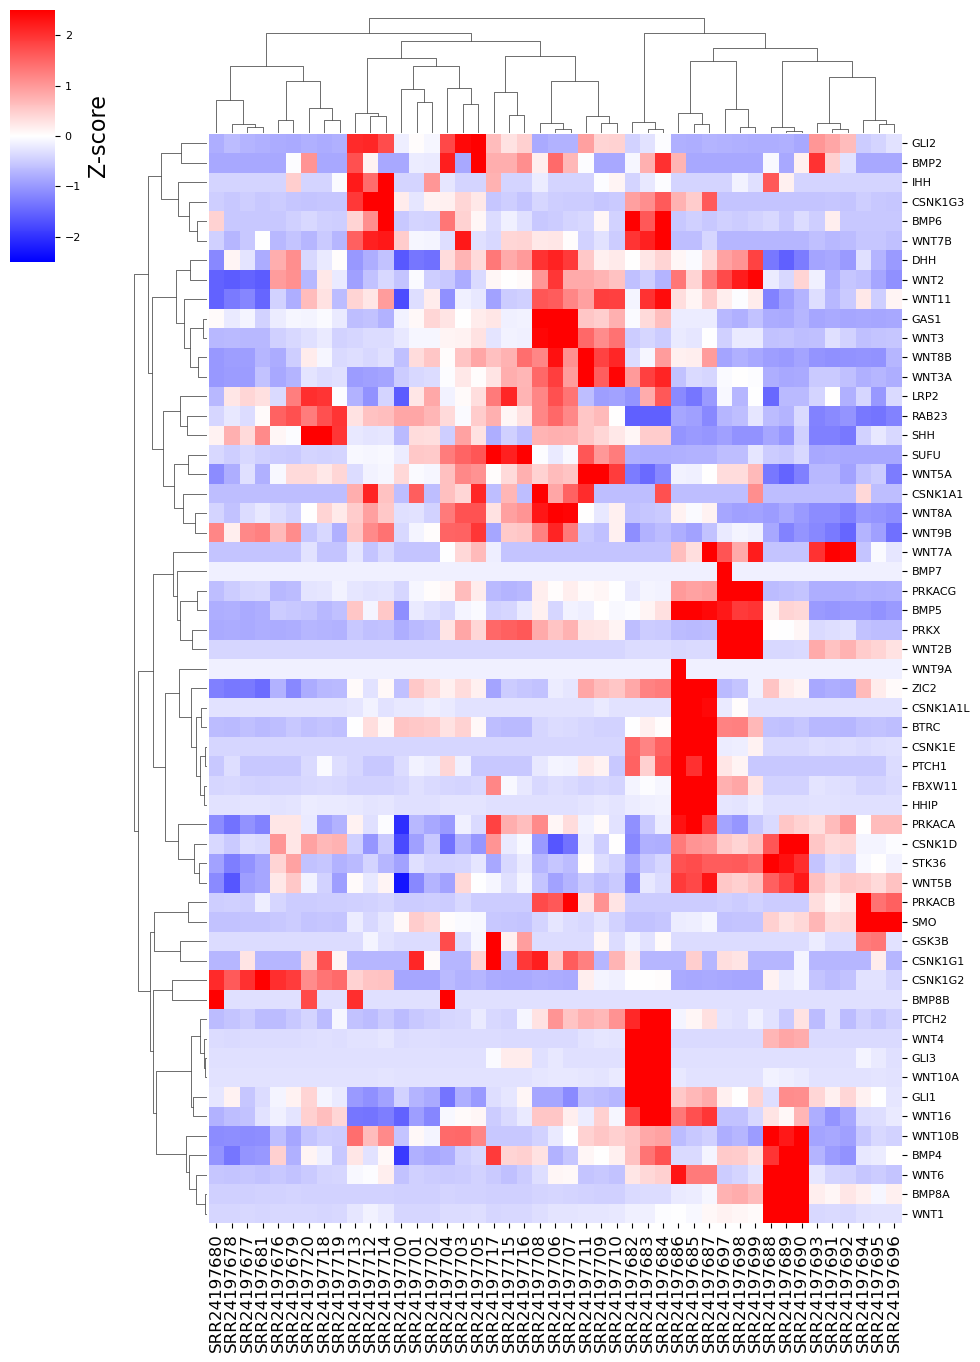

In [10]:
# euclidean ward seems to work fine
# correlation average also seems good
# correlation complete is the best with top 20
# cosine average good
g = seaborn.clustermap(
    df_zscore,
    metric='correlation',     # distance metric
    method='complete',       # clustering method (e.g., single, complete, average, ward)
    cmap='bwr',            # color map (others: 'coolwarm', 'viridis', 'mako', 'rocket')
    standard_scale=None,    # or 0 (rows) or 1 (columns) if you didn't z-score earlier
    figsize=(9, 14),
    #col_colors=group_colors,
    #row_colors=row_colors,
    dendrogram_ratio=(0.1, 0.1),  # adjust size of dendrograms
    cbar_pos=(-0.1, 0.8, 0.05, 0.18),  # colorbar position
    xticklabels=True,
    cbar_kws={'label': 'Z-score'},
    vmin=-2.5,
    vmax=2.5,
    yticklabels=True
)